In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.
from sklearn.metrics import  accuracy_score,f1_score,confusion_matrix
data= pd.read_csv("dataset.csv")
data.mental_health_risk.value_counts()




mental_health_risk
1    11823
0     9357
2     3820
Name: count, dtype: int64

In [3]:
#binary classification
#extract the data
bdata=[]
for i in range(len(data)):
    if data.mental_health_risk[i]!=2:
        bdata.append(data.loc[i])
bdata=pd.DataFrame(bdata)  
bdata.index=range(len(bdata))  
print(bdata.mental_health_risk.value_counts())
bdata.head()  

mental_health_risk
1    11823
0     9357
Name: count, dtype: int64


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0
3,58,Male,Married,Master,Employed,9.4,12.8,5.9,7,7,...,6,3,1,3,0,0,1,0,0,0
4,22,Other,Married,PhD,Employed,6.9,11.6,6.4,10,10,...,4,5,7,7,0,0,0,0,1,0


In [4]:
#split the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(bdata.drop("mental_health_risk",axis=1),bdata.mental_health_risk,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# align columns (important)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


(16944, 24) (4236, 24) (16944,) (4236,)


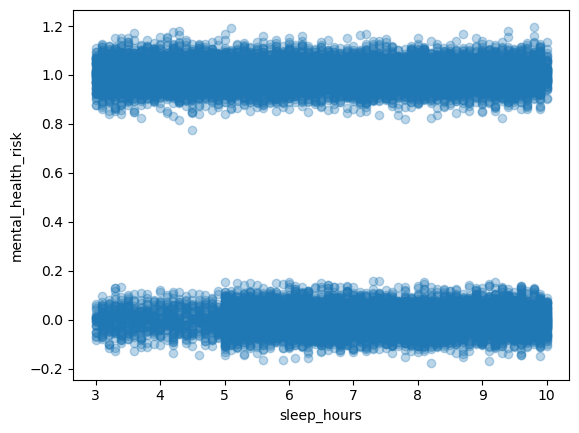

In [5]:
import numpy as np

y_jitter = bdata['mental_health_risk'] + np.random.normal(0, 0.05, size=len(bdata))

plt.scatter(bdata['sleep_hours'], y_jitter, alpha=0.3)
plt.xlabel('sleep_hours')
plt.ylabel('mental_health_risk')
plt.show()

In [ ]:
model= LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

accuracy 0.7974504249291785
f1 score 0.8228004956629492
confusion matrix [[1386  481]
 [ 377 1992]]


In [ ]:
model= LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("f1 score",f1_score(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

In [28]:
from sklearn.tree import DecisionTreeClassifier
tree= DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(x_train, y_train)
y_pred_tree= tree.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_tree))
print("f1 score",f1_score(y_test,y_pred_tree))
print("confusion matrix",confusion_matrix(y_test,y_pred_tree))


accuracy 0.9990557129367328
f1 score 0.9991554054054054
confusion matrix [[1866    1]
 [   3 2366]]


In [80]:
from sklearn.ensemble import RandomForestClassifier
np.random.shuffle(y_test)
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=25)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred_rf))
print("f1 score",f1_score(y_test,y_pred_rf))
print("confusion matrix",confusion_matrix(y_test,y_pred_rf))

accuracy 0.516052880075543
f1 score 0.5667793744716821
confusion matrix [[ 845 1022]
 [1028 1341]]


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

In [ ]:
import numpy as np
np.random.shuffle(y_test)
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("accuracy", accuracy_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("confusion matrix", confusion_matrix(y_test, y_pred))


accuracy 0.5118035882908404
f1 score 0.5635289151540734
confusion matrix [[ 833 1034]
 [1034 1335]]
